# Implementation PyTorch Layer

In [1]:
import matplotlib.pyplot as plt
import librosa
import torch
import torchaudio

def plot_spectrogram(specgram, title=None, ylabel="mel_bin", ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.imshow(librosa.power_to_db(specgram), origin="lower", aspect="auto", interpolation="nearest")

In [2]:
signal, sr = torchaudio.load("844922__modusmogulus__pad-colorbass-bliss-in-glitches-02.wav")
resample = torchaudio.transforms.Resample(orig_freq=sr, new_freq=16000)

signal_16k, sr = resample(signal), 16_000

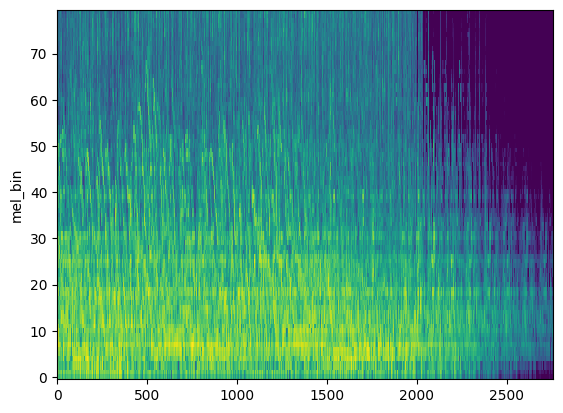

In [3]:
# Spectrogram by the torch function
melspec = torchaudio.transforms.MelSpectrogram(
    hop_length=160,
    n_mels=80
)(signal[0])

plot_spectrogram(melspec)

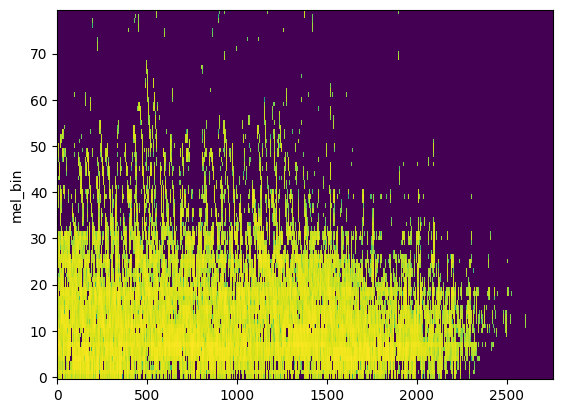

In [4]:
# Own spectrogram implementation

from melbanks import LogMelFilterBanks

mel = LogMelFilterBanks()
logmel_spec = mel.forward(signal[0])
plot_spectrogram(logmel_spec)

In [5]:
assert torch.log(melspec + 1e-6).shape == logmel_spec.shape
assert torch.allclose(torch.log(melspec + 1e-6), logmel_spec)

# Training Simple CNN model

In [6]:
import time
import torch.nn as nn
import torch.nn.functional as F_nn
from torch.utils.data import DataLoader
from torchaudio.datasets import SPEECHCOMMANDS
from pathlib import Path
from melbanks import LogMelFilterBanks

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

MAX_LEN = 16000
LABELS = {"yes": 1, "no": 0}
BATCH_SIZE = 64


class YesNoSC(SPEECHCOMMANDS):
    """SPEECHCOMMANDS filtered to yes/no binary classification."""

    def __init__(self, subset):
        super().__init__(root="./data", subset=subset, download=True)
        self._walker = [w for w in self._walker if Path(w).parent.name in LABELS]

    def __getitem__(self, n):
        waveform, sr, label, *_ = super().__getitem__(n)
        if waveform.shape[1] < MAX_LEN:
            waveform = F_nn.pad(waveform, (0, MAX_LEN - waveform.shape[1]))
        else:
            waveform = waveform[:, :MAX_LEN]
        return waveform.squeeze(0), LABELS[label]


train_ds = YesNoSC("training")
val_ds = YesNoSC("validation")
test_ds = YesNoSC("testing")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Device: cuda
Train: 6358, Val: 803, Test: 824


In [7]:
class AudioCNN(nn.Module):
    def __init__(self, n_mels=80, groups=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(n_mels, 64, kernel_size=3, padding=1, groups=groups),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 64, kernel_size=3, padding=1, groups=groups),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 32, kernel_size=3, padding=1, groups=groups),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).squeeze(-1)
        return self.fc(x).squeeze(-1)


# Quick check
model = AudioCNN(n_mels=80, groups=1)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

AudioCNN(
  (features): Sequential(
    (0): Conv1d(80, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Parameters: 34,305


In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def count_flops(model, input_tensor):
    """Estimate FLOPs for Conv1d + Linear layers (single sample)."""
    flops = [0]
    hooks = []

    def conv1d_hook(module, inp, out):
        out_len = out.shape[-1]
        kernel_ops = (module.in_channels // module.groups) * module.kernel_size[0]
        flops[0] += 2 * kernel_ops * module.out_channels * out_len

    def linear_hook(module, inp, out):
        flops[0] += 2 * module.in_features * module.out_features

    for m in model.modules():
        if isinstance(m, nn.Conv1d):
            hooks.append(m.register_forward_hook(conv1d_hook))
        elif isinstance(m, nn.Linear):
            hooks.append(m.register_forward_hook(linear_hook))

    with torch.no_grad():
        model(input_tensor)

    for h in hooks:
        h.remove()

    return flops[0]


def train_epoch(model, mel_transform, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    n_samples = 0
    for waveforms, labels in loader:
        waveforms, labels = waveforms.to(device), labels.to(device)
        with torch.no_grad():
            features = mel_transform(waveforms)
        outputs = model(features)
        loss = criterion(outputs, labels.float())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        n_samples += len(labels)
    return total_loss / n_samples


def evaluate(model, mel_transform, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for waveforms, labels in loader:
            waveforms, labels = waveforms.to(device), labels.to(device)
            features = mel_transform(waveforms)
            outputs = model(features)
            preds = (torch.sigmoid(outputs) > 0.5).long()
            correct += (preds == labels).sum().item()
            total += len(labels)
    return correct / total

In [8]:
def run_experiment(n_mels=80, groups=1, epochs=20, lr=1e-3):
    mel = LogMelFilterBanks(n_mels=n_mels).to(device)
    model = AudioCNN(n_mels=n_mels, groups=groups).to(device)

    n_params = count_params(model)
    dummy = mel(torch.randn(1, MAX_LEN, device=device))
    flops = count_flops(model, dummy)

    print(f"n_mels={n_mels}, groups={groups} | Params: {n_params:,} | FLOPs: {flops:,}")

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    history = {"train_loss": [], "val_acc": [], "epoch_time": []}

    for epoch in range(epochs):
        t0 = time.time()
        loss = train_epoch(model, mel, train_loader, optimizer, criterion)
        epoch_time = time.time() - t0
        val_acc = evaluate(model, mel, val_loader)

        history["train_loss"].append(loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{epochs} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f} | Time: {epoch_time:.1f}s")

    test_acc = evaluate(model, mel, test_loader)
    print(f"  Test Accuracy: {test_acc:.4f}\n")

    return {
        "model": model, "history": history, "test_acc": test_acc,
        "n_params": n_params, "flops": flops,
    }

## Experiment 1: varying n_mels (20, 40, 80)

In [11]:
results_mels = {}
for n_mels in [20, 40, 80]:
    print(f"{'=' * 50}")
    results_mels[n_mels] = run_experiment(n_mels=n_mels, groups=1, epochs=20)

n_mels=20, groups=1 | Params: 22,785 | FLOPs: 2,311,744
  Epoch 5/20 | Loss: 0.0604 | Val Acc: 0.9900 | Time: 4.6s
  Epoch 10/20 | Loss: 0.0306 | Val Acc: 0.9925 | Time: 4.6s
  Epoch 15/20 | Loss: 0.0216 | Val Acc: 0.9900 | Time: 4.6s
  Epoch 20/20 | Loss: 0.0223 | Val Acc: 0.9900 | Time: 4.6s
  Test Accuracy: 0.9964

n_mels=40, groups=1 | Params: 26,625 | FLOPs: 3,087,424
  Epoch 5/20 | Loss: 0.0676 | Val Acc: 0.9776 | Time: 4.6s
  Epoch 10/20 | Loss: 0.0353 | Val Acc: 0.9938 | Time: 4.6s
  Epoch 15/20 | Loss: 0.0247 | Val Acc: 0.9888 | Time: 4.7s
  Epoch 20/20 | Loss: 0.0161 | Val Acc: 0.9888 | Time: 4.6s
  Test Accuracy: 0.9891

n_mels=80, groups=1 | Params: 34,305 | FLOPs: 4,638,784
  Epoch 5/20 | Loss: 0.0620 | Val Acc: 0.9838 | Time: 4.6s
  Epoch 10/20 | Loss: 0.0408 | Val Acc: 0.9527 | Time: 4.7s
  Epoch 15/20 | Loss: 0.0263 | Val Acc: 0.9863 | Time: 4.6s
  Epoch 20/20 | Loss: 0.0207 | Val Acc: 0.9838 | Time: 4.7s
  Test Accuracy: 0.9976



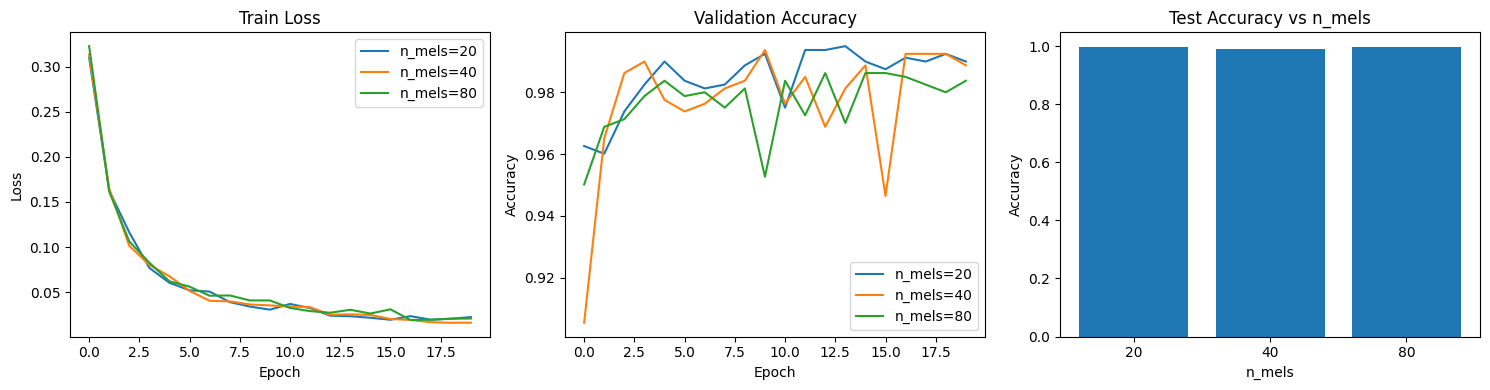

In [12]:
# n_mels plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for n_mels, res in results_mels.items():
    axes[0].plot(res["history"]["train_loss"], label=f"n_mels={n_mels}")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

for n_mels, res in results_mels.items():
    axes[1].plot(res["history"]["val_acc"], label=f"n_mels={n_mels}")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

mels_list = list(results_mels.keys())
axes[2].bar([str(m) for m in mels_list], [results_mels[m]["test_acc"] for m in mels_list])
axes[2].set_title("Test Accuracy vs n_mels")
axes[2].set_xlabel("n_mels")
axes[2].set_ylabel("Accuracy")

plt.tight_layout()
plt.savefig("n_mels_comparison.png", dpi=150)
plt.show()

## Experiment 2: varying groups (1, 2, 4, 8, 16) with baseline n_mels=80

In [13]:
results_groups = {}
for groups in [1, 2, 4, 8, 16]:
    print(f"{'=' * 50}")
    results_groups[groups] = run_experiment(n_mels=80, groups=groups, epochs=20)

n_mels=80, groups=1 | Params: 34,305 | FLOPs: 4,638,784
  Epoch 5/20 | Loss: 0.0637 | Val Acc: 0.9813 | Time: 4.7s
  Epoch 10/20 | Loss: 0.0338 | Val Acc: 0.9888 | Time: 4.6s
  Epoch 15/20 | Loss: 0.0221 | Val Acc: 0.9838 | Time: 4.7s
  Epoch 20/20 | Loss: 0.0186 | Val Acc: 0.9676 | Time: 4.6s
  Test Accuracy: 0.9806

n_mels=80, groups=2 | Params: 17,409 | FLOPs: 2,319,424
  Epoch 5/20 | Loss: 0.0735 | Val Acc: 0.9527 | Time: 4.6s
  Epoch 10/20 | Loss: 0.0454 | Val Acc: 0.9078 | Time: 4.7s
  Epoch 15/20 | Loss: 0.0286 | Val Acc: 0.9875 | Time: 4.8s
  Epoch 20/20 | Loss: 0.0197 | Val Acc: 0.9813 | Time: 4.6s
  Test Accuracy: 0.9927

n_mels=80, groups=4 | Params: 8,961 | FLOPs: 1,159,744
  Epoch 5/20 | Loss: 0.1223 | Val Acc: 0.9689 | Time: 4.7s
  Epoch 10/20 | Loss: 0.0638 | Val Acc: 0.9801 | Time: 4.6s
  Epoch 15/20 | Loss: 0.0432 | Val Acc: 0.9776 | Time: 4.8s
  Epoch 20/20 | Loss: 0.0345 | Val Acc: 0.9863 | Time: 4.7s
  Test Accuracy: 0.9879

n_mels=80, groups=8 | Params: 4,737 | FLO

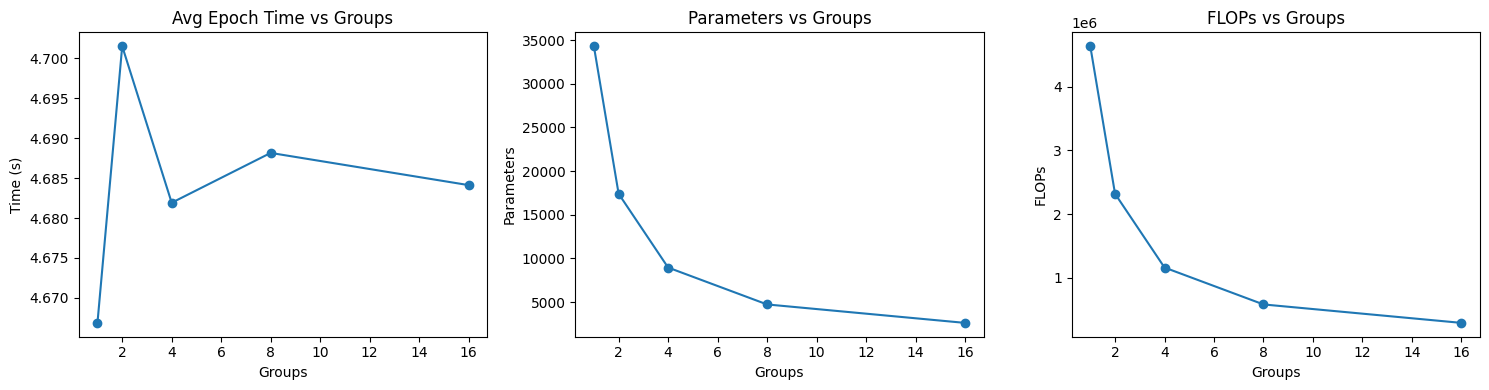


Groups | Params    | FLOPs       | Test Acc
--------------------------------------------------
     1 |    34,305 |   4,638,784 | 0.9806
     2 |    17,409 |   2,319,424 | 0.9927
     4 |     8,961 |   1,159,744 | 0.9879
     8 |     4,737 |     579,904 | 0.9745
    16 |     2,625 |     289,984 | 0.9757


In [14]:
# groups plots
groups_list = sorted(results_groups.keys())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

avg_times = [sum(results_groups[g]["history"]["epoch_time"]) / len(results_groups[g]["history"]["epoch_time"]) for g in groups_list]
axes[0].plot(groups_list, avg_times, "o-")
axes[0].set_title("Avg Epoch Time vs Groups")
axes[0].set_xlabel("Groups")
axes[0].set_ylabel("Time (s)")

axes[1].plot(groups_list, [results_groups[g]["n_params"] for g in groups_list], "o-")
axes[1].set_title("Parameters vs Groups")
axes[1].set_xlabel("Groups")
axes[1].set_ylabel("Parameters")

axes[2].plot(groups_list, [results_groups[g]["flops"] for g in groups_list], "o-")
axes[2].set_title("FLOPs vs Groups")
axes[2].set_xlabel("Groups")
axes[2].set_ylabel("FLOPs")

plt.tight_layout()
plt.savefig("groups_comparison.png", dpi=150)
plt.show()

# Test accuracy table
print("\nGroups | Params    | FLOPs       | Test Acc")
print("-" * 50)
for g in groups_list:
    r = results_groups[g]
    print(f"  {g:>4} | {r['n_params']:>9,} | {r['flops']:>11,} | {r['test_acc']:.4f}")